In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)


In [2]:
df=pd.read_csv("E:\deep_learning\Churn_Modelling.csv")

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditScore   

In [4]:
print(df.columns.tolist())

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [5]:
# Unnecessary columns remove
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Categorical columns convert into numerical
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

# Features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

             Algorithm  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8105   0.547945  0.203562  0.296846
1                  KNN    0.8250   0.589212  0.361323  0.447950
2        Decision Tree    0.8575   0.764706  0.396947  0.522613


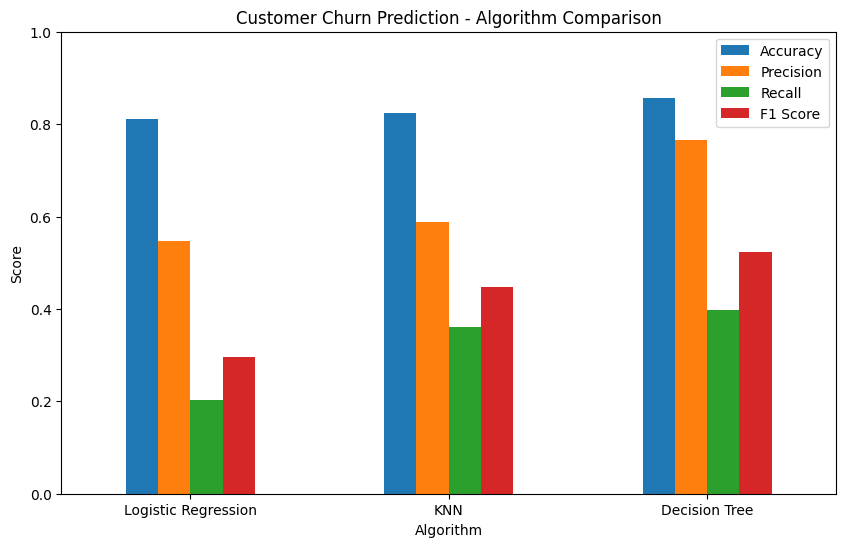

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Logistic Regression


lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)



# 2. KNN


knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)



# 3. Decision Tree


dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)



# 4. Comparison


results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ]
})

print(results)


# =========================
# 5. Graph
# =========================

results.set_index('Algorithm').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Customer Churn Prediction - Algorithm Comparison')
plt.ylabel('Score')
plt.xlabel('Algorithm')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()